In [48]:
import pandas as pd

In [49]:
df=pd.read_csv('ToyotaCorolla.csv')

In [50]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [51]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [52]:
import matplotlib.pyplot as plt

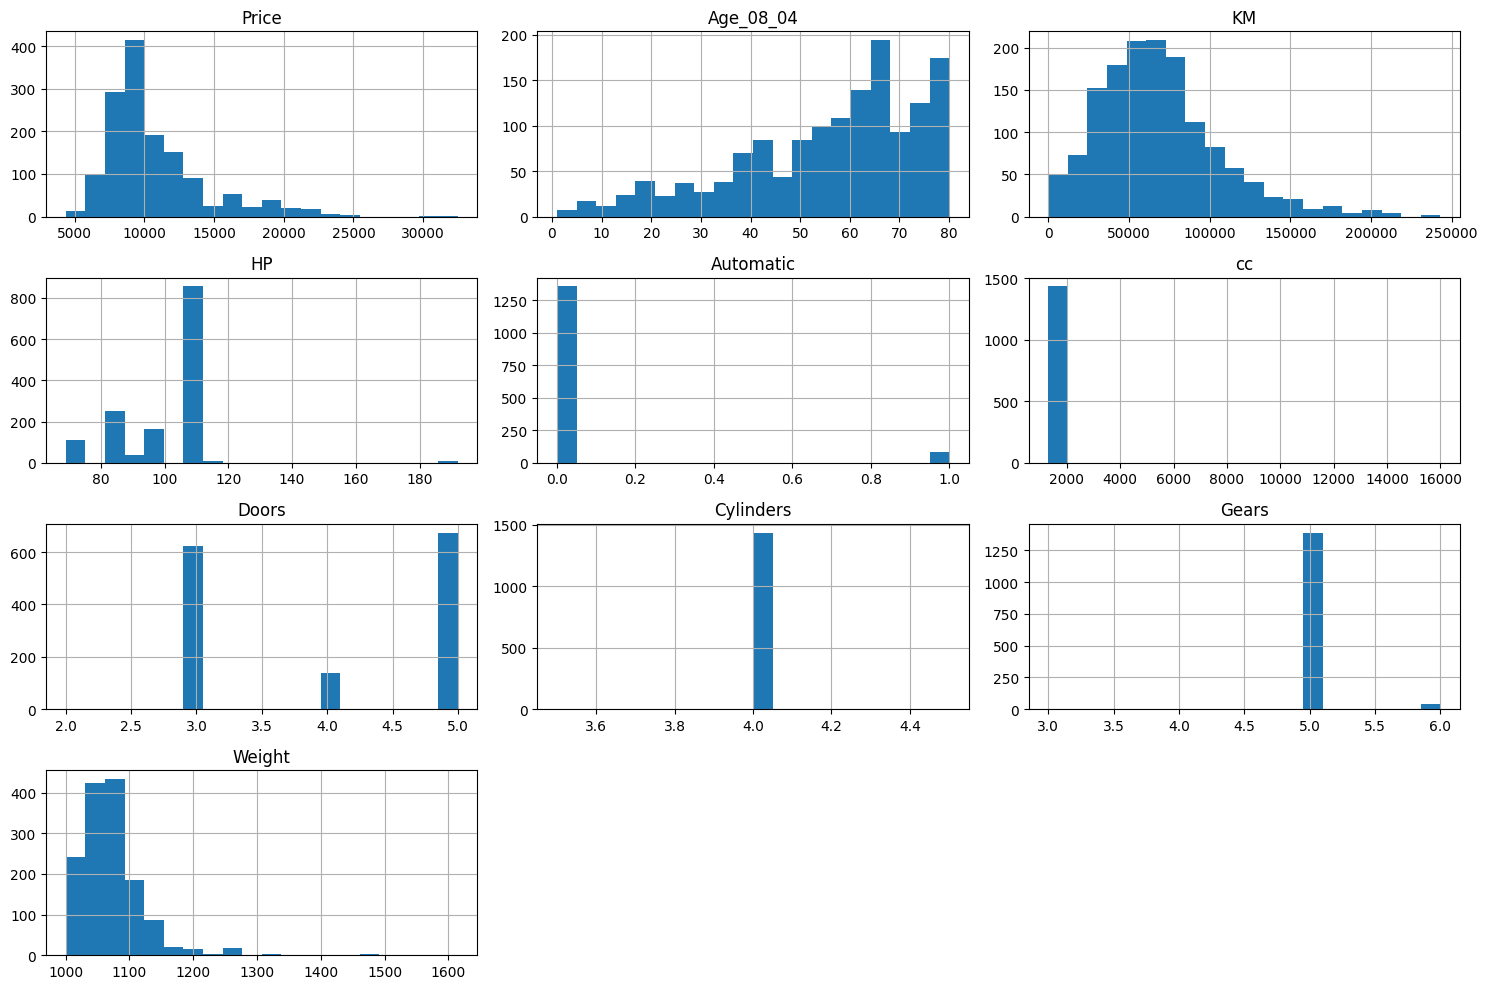

In [53]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()


In [54]:
import numpy as np
import seaborn as sns

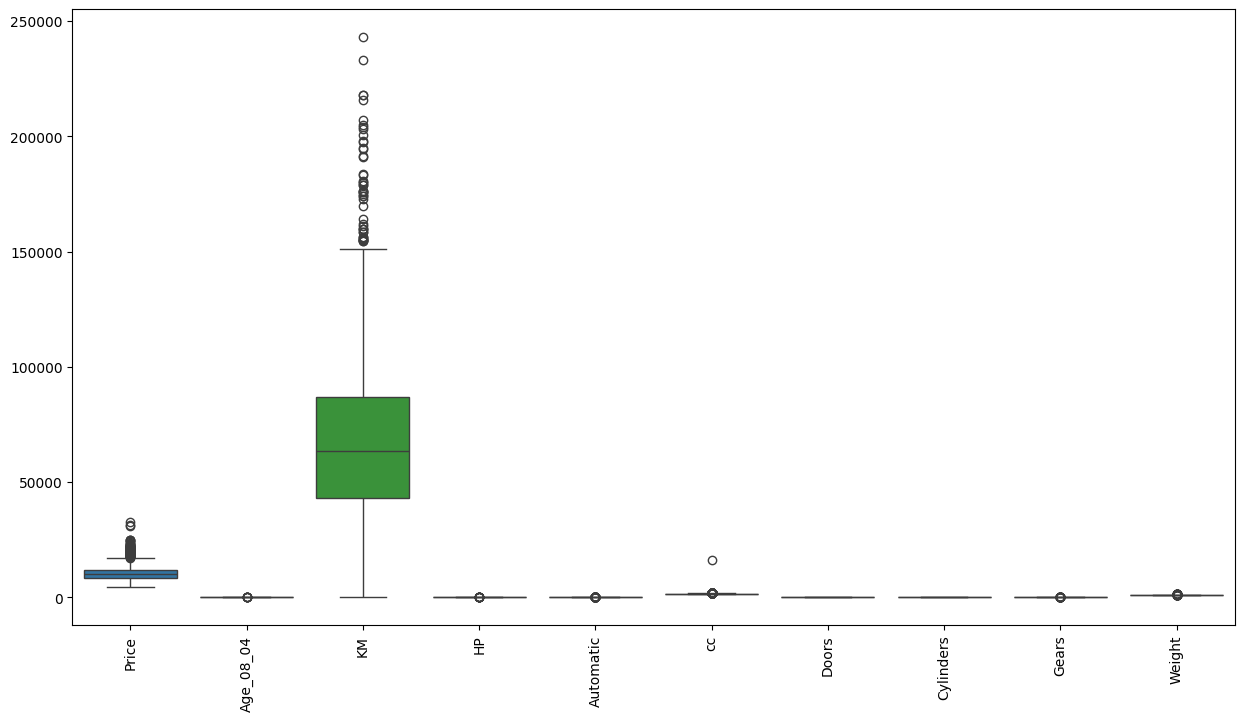

In [55]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()


In [56]:
num_cols = df.select_dtypes(include=np.number).columns

In [57]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


In [58]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986.0,Diesel,90,0,1900,3,4,5,1152.5
1,13750,23,72937.0,Diesel,90,0,1900,3,4,5,1152.5
2,13950,24,41711.0,Diesel,90,0,1900,3,4,5,1152.5
3,14950,26,48000.0,Diesel,90,0,1900,3,4,5,1152.5
4,13750,30,38500.0,Diesel,90,0,1900,3,4,5,1152.5


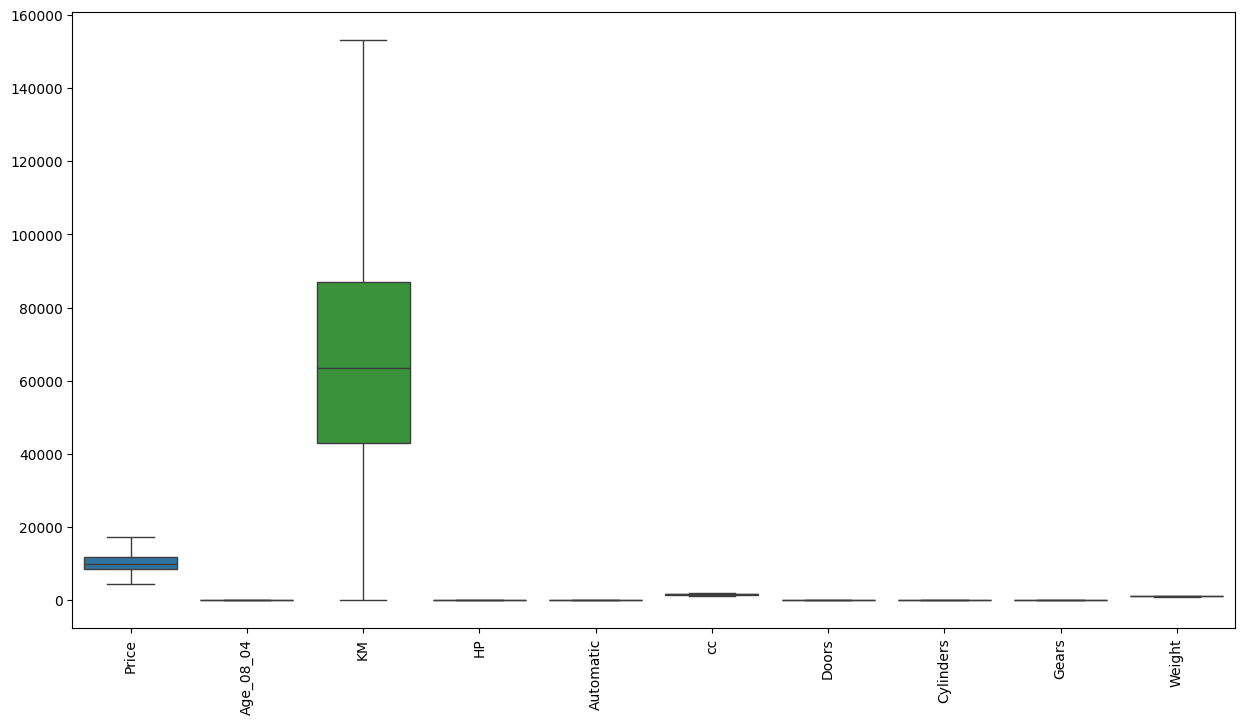

In [59]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


In [62]:
X = df.drop(columns=["Price"])
y = df["Price"]


In [63]:
X = pd.get_dummies(X, drop_first=True)


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


###### Model 1:Simple MLR

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [67]:
lr = LinearRegression()
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})
coeff_df.sort_values(by="Coefficient", ascending=False)


,Feature,Coefficient
8,Weight,9.437243e+02
10,Fuel_Type_Petrol,4.167109e+02
9,Fuel_Type_Diesel,3.629008e+02
2,HP,3.593123e+02
3,Automatic,2.216893e-12
7,Gears,0.000000e+00
6,Cylinders,-2.486900e-13
5,Doors,-9.303490e+01
4,cc,-4.225217e+02
1,KM,-4.974739e+02


###### Model 2:MLR using Statsmodels (for p-values)

In [69]:
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

In [70]:
X_sm = sm.add_constant(X_scaled)
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     1155.
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:51:41   Log-Likelihood:                -12081.
No. Observations:                1436   AIC:                         2.418e+04
Df Residuals:                    1427   BIC:                         2.423e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.05e+04     28.863    363.804      0.0

###### Model 3:Reduced Feature model


In [73]:
corr = df[num_cols].corr()["Price"].sort_values(ascending=False)
top_features = corr.index[1:6]

X_reduced = df[top_features]
X_reduced = scaler.fit_transform(X_reduced)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

lr_reduced = LinearRegression()
lr_reduced.fit(X_train_r, y_train_r)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))


In [75]:
print("Full MLR Model:")
evaluate_model(lr, X_test, y_test)

print("\nReduced MLR Model:")
evaluate_model(lr_reduced, X_test_r, y_test_r)


Full MLR Model:
MAE: 831.3726520676909
MSE: 1179909.6024343504
RMSE: 1086.2364394708688
R2 Score: 0.8626684189497995

Reduced MLR Model:
MAE: 1318.0187186026792
MSE: 3075013.679069327
RMSE: 1753.5716920244029
R2 Score: 0.6420941999062333


In [76]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

evaluate_model(ridge, X_test, y_test)


MAE: 831.218657942961
MSE: 1179890.7799203421
RMSE: 1086.2277753401181
R2 Score: 0.8626706097325534


In [77]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

evaluate_model(lasso, X_test, y_test)


MAE: 831.3692552877217
MSE: 1179906.6035289168
RMSE: 1086.2350590590036
R2 Score: 0.8626687679972382


In [78]:
lasso_coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

lasso_coeff[lasso_coeff["Coefficient"] != 0]


,Feature,Coefficient
0,Age_08_04,-1975.190635
1,KM,-497.500423
2,HP,359.012338
4,cc,-422.165739
5,Doors,-93.013747
8,Weight,943.667917
9,Fuel_Type_Diesel,362.355463
10,Fuel_Type_Petrol,416.551358


### Interview Questions

#### What is Normalization & Standardization and how is it helpful?

##### 1. Normalization

**Definition:**
Rescaling data so that all feature values lie within a specific range, usually 0 to 1.

**Important Points:**

Useful when features have different scales.

Often used in neural networks and distance-based algorithms like KNN or K-Means.

**Sensitive to outliers.**

Makes features comparable and ensures no single feature dominates.

##### 2. Standardization

**Definition:**
Transforming data so that it has a mean of 0 and a standard deviation of 1.

**Important Points:**

Useful when features have different scales, especially if data is normally distributed.

Common in linear regression, logistic regression, PCA, and SVM.

**Less sensitive to outliers than normalization.**

Centers the data and makes it suitable for models assuming normal distribution.

#### What techniques can be used to address multicollinearity in multiple linear regression?

**1. Remove Highly Correlated Variables**

Identify variables with high correlation (using a correlation matrix or VIF).

Drop one of the correlated variables to reduce redundancy.

**2. Combine Variables**

Combine correlated features into a single feature.

Example: If height_cm and weight_kg are correlated, you might create BMI as a new feature.

**3. Principal Component Analysis (PCA)**

Transform correlated features into a set of uncorrelated components.

Use these components as predictors instead of original variables.

**4. Regularization Techniques**

Ridge Regression (L2): Penalizes large coefficients, reducing impact of multicollinearity.

Lasso Regression (L1): Can shrink some coefficients to zero, effectively performing feature selection.

**5. Increase Sample Size**

Sometimes multicollinearity issues decrease with more data, as it reduces variance in coefficient estimates.

### Assumptions of Multiple Linear Regression

**Assumption**	
- Linearity	
- No Multicollinearity	
- Homoscedasticity	
- Normality of errors	
- Independence	

**Implication**
- Relationship must be linear
- Predictors should not be highly correlated
- Constant variance of errors
- Improves inference
- Observations independent
